In [3]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json

from src.plot_style import set_plot_style

set_plot_style()

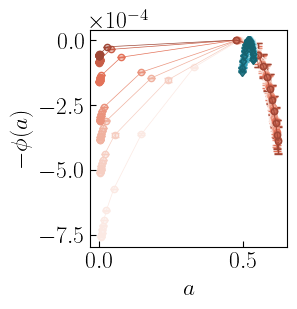

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import json

def cm_to_inch(cm):
    return cm / 2.54

panel_width_cm = 5.0
panel_height_cm = 5.5
margin_cm = 2.0

fig_width = cm_to_inch(panel_width_cm + 2 * margin_cm)
fig_height = cm_to_inch(panel_height_cm + 2 * margin_cm)

fig = plt.figure(figsize=(fig_width, fig_height))

left = margin_cm / (panel_width_cm + 2 * margin_cm)
bottom = margin_cm / (panel_height_cm + 2 * margin_cm)
width = panel_width_cm / (panel_width_cm + 2 * margin_cm)
height = panel_height_cm / (panel_height_cm + 2 * margin_cm)

ax = fig.add_axes([left, bottom, width, height])

with open("data/rate_function_data.json", "r") as f:
    data = json.load(f)

V_values = [5.875, 2.000]
num_sites_range = [4, 6, 8, 10, 20, 40, 60]

gradient_teal_1 = ["#E4F3F6","#B8E0E7","#82C9D6","#4FB2C6","#2C9CB5","#1F7F95","#166370"]
gradient_teal_03 = [(228/255, 243/255, 246/255, 0.3),(184/255, 224/255, 231/255, 0.3),
                     (130/255, 201/255, 214/255, 0.3),(79/255, 178/255, 198/255, 0.3),
                     (44/255, 156/255, 181/255, 0.3),(31/255, 127/255, 149/255, 0.3),
                     (22/255, 99/255, 112/255, 0.3)]
gradient_orange_1 = ["#FBE9E3","#F6CFC3","#F0B2A0","#EA937D","#E37259","#C85D47","#9F4736"]
gradient_orange_03 = [(251/255, 233/255, 227/255, 0.3),(246/255, 207/255, 195/255, 0.3),
                       (240/255, 178/255, 160/255, 0.3),(234/255, 147/255, 125/255, 0.3),
                       (227/255, 114/255, 89/255, 0.3),(200/255, 93/255, 71/255, 0.3),
                       (159/255, 71/255, 54/255, 0.3)]

for i, V in enumerate(V_values):
    if V == 5.875:
        colors = gradient_orange_03
        darker_colors = gradient_orange_1
        marker = 'o'
    else:
        colors = gradient_teal_03
        darker_colors = gradient_teal_1
        marker = 'd'
    for n, L in enumerate(num_sites_range):
        key_a = f"activity_V_{V}_L_{L}"
        key_phi = f"phi_V_{V}_L_{L}"
        key_err = f"errors_V_{V}_L_{L}"

        a_vals = np.array(data[key_a])
        phi_vals = np.array(data[key_phi])
        err_vals = np.array(data[key_err])

        ax.errorbar(a_vals,phi_vals,yerr=err_vals,linestyle='None',capsize=3,elinewidth=1,color=darker_colors[n],zorder=1)

        ax.plot(a_vals,phi_vals,marker=marker,markersize=4.5,markerfacecolor=colors[n],markeredgecolor=darker_colors[n],lw=0.5,color=darker_colors[n])

ax.set_xlabel(r"$a$", fontsize=17)
ax.set_ylabel(r"$-\phi(a)$", fontsize=17)

ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

from matplotlib.ticker import ScalarFormatter
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

plt.savefig("figures/svg/fig3_c.svg", dpi=300, transparent=True)
plt.savefig("figures/pdf/fig3_c.pdf", dpi=300, transparent=True)
plt.show()